In [1]:
import os, sys

# Go up one level from the notebook folder to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(project_root)

# Add to path for module imports
sys.path.append(project_root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import ta


In [3]:
df = pd.read_csv("data/AAPL_historical.csv", parse_dates=["Date"], index_col="Date")
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.columns = df.columns.str.lower()
df.tail()


,open,high,low,close,volume
Date,,,,,
2025-06-18 00:00:00-04:00,195.940002,197.570007,195.070007,196.580002,45394700
2025-06-20 00:00:00-04:00,198.240005,201.699997,196.860001,201.000000,96813500
2025-06-23 00:00:00-04:00,201.630005,202.300003,198.960007,201.500000,55814300
2025-06-24 00:00:00-04:00,202.589996,203.440002,200.199997,200.300003,54064000
2025-06-25 00:00:00-04:00,201.449997,203.669998,200.619995,201.559998,39454000


In [4]:
df['return'] = df['close'].pct_change()
df['ma_7'] = df['close'].rolling(window=7).mean()
df['ma_21'] = df['close'].rolling(window=21).mean()
df['rsi'] = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
df['volume_change'] = df['volume'].pct_change()
df.dropna(inplace=True)
df.tail()


,open,high,low,close,volume,return,ma_7,ma_21,rsi,volume_change
Date,,,,,,,,,,
2025-06-18 00:00:00-04:00,195.940002,197.570007,195.070007,196.580002,45394700,0.004805,198.248570,200.406667,42.356616,0.168274
2025-06-20 00:00:00-04:00,198.240005,201.699997,196.860001,201.000000,96813500,0.022484,198.009999,200.127619,49.674578,1.132705
2025-06-23 00:00:00-04:00,201.630005,202.300003,198.960007,201.500000,55814300,0.002488,198.398570,200.099524,50.441048,-0.423486
2025-06-24 00:00:00-04:00,202.589996,203.440002,200.199997,200.300003,54064000,-0.005955,198.555714,200.049048,48.530671,-0.031359
2025-06-25 00:00:00-04:00,201.449997,203.669998,200.619995,201.559998,39454000,0.006291,199.285714,200.348572,50.644378,-0.270235


In [5]:
scaler = StandardScaler()
feature_cols = ['open', 'high', 'low', 'volume', 'return', 'ma_7', 'ma_21', 'rsi', 'volume_change']
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])
df_scaled.tail()
# Add this: scale the target as well
target_scaler = StandardScaler()
df_scaled['close'] = target_scaler.fit_transform(df[['close']])


In [6]:
class StockSequenceDataset(Dataset):
    def __init__(self, df, target_col='close', seq_len=20):
        self.seq_len = seq_len
        self.data = df.drop(columns=[target_col]).values
        self.targets = df[target_col].values

    def __len__(self):
        return len(self.targets) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.targets[idx + self.seq_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [7]:
# Split the DataFrame into train and test
seq_len = 20
train_size = int(len(df_scaled) * 0.8)

train_df = df_scaled.iloc[:train_size]
test_df = df_scaled.iloc[train_size - seq_len:]  # retain overlap for sequence

# Create datasets
train_dataset = StockSequenceDataset(train_df, target_col='close', seq_len=seq_len)
test_dataset = StockSequenceDataset(test_df, target_col='close', seq_len=seq_len)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


In [9]:
model = LSTMModel(input_size=df_scaled.shape[1] - 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(x_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss / len(train_loader):.4f}")


Epoch 1 | Loss: 0.4460
Epoch 2 | Loss: 0.0525
Epoch 3 | Loss: 0.0206
Epoch 4 | Loss: 0.0131
Epoch 5 | Loss: 0.0111
Epoch 6 | Loss: 0.0106
Epoch 7 | Loss: 0.0106
Epoch 8 | Loss: 0.0096
Epoch 9 | Loss: 0.0091
Epoch 10 | Loss: 0.0110
Epoch 11 | Loss: 0.0093
Epoch 12 | Loss: 0.0097
Epoch 13 | Loss: 0.0094
Epoch 14 | Loss: 0.0097
Epoch 15 | Loss: 0.0103
Epoch 16 | Loss: 0.0086
Epoch 17 | Loss: 0.0097
Epoch 18 | Loss: 0.0084
Epoch 19 | Loss: 0.0087
Epoch 20 | Loss: 0.0086
Epoch 21 | Loss: 0.0079
Epoch 22 | Loss: 0.0084
Epoch 23 | Loss: 0.0088
Epoch 24 | Loss: 0.0118
Epoch 25 | Loss: 0.0117
Epoch 26 | Loss: 0.0095
Epoch 27 | Loss: 0.0083
Epoch 28 | Loss: 0.0087
Epoch 29 | Loss: 0.0084
Epoch 30 | Loss: 0.0085
Epoch 31 | Loss: 0.0097
Epoch 32 | Loss: 0.0111
Epoch 33 | Loss: 0.0077
Epoch 34 | Loss: 0.0085
Epoch 35 | Loss: 0.0081
Epoch 36 | Loss: 0.0080
Epoch 37 | Loss: 0.0079
Epoch 38 | Loss: 0.0087
Epoch 39 | Loss: 0.0084
Epoch 40 | Loss: 0.0080
Epoch 41 | Loss: 0.0093
Epoch 42 | Loss: 0.0080
E

📊 Test MSE: 60.4744
📉 Test MAE: 6.0198


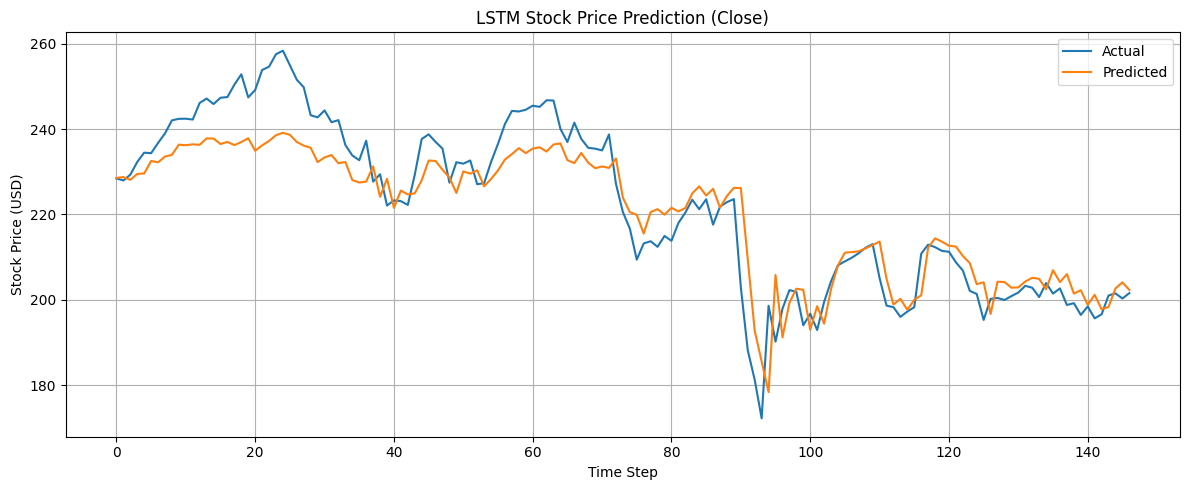

In [13]:
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model(x_batch).squeeze()
        preds.extend(output.numpy())
        actuals.extend(y_batch.numpy())

# Inverse transform to convert predictions back to actual price scale
preds = target_scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
actuals = target_scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(actuals, preds)
mae = mean_absolute_error(actuals, preds)

print(f"📊 Test MSE: {mse:.4f}")
print(f"📉 Test MAE: {mae:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(actuals, label='Actual')
plt.plot(preds, label='Predicted')
plt.title("LSTM Stock Price Prediction (Close)")
plt.xlabel("Time Step")  # X-axis: index of test data
plt.ylabel("Stock Price (USD)")  # Y-axis: price
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

